# 🏥 Phase 3: LSTM & Vision Transformer — Medical Image Diagnosis
## Supervised Learning — Spring 2026
### Cairo University, Faculty of Computers and Artificial Intelligence

---
**Your Task:**
- LSTM model on NIH Chest X-Ray (image rows as sequences)
- Fine-tuned Vision Transformer (ViT) on NIH Chest X-Ray
- Attention Visualization (heatmaps)
- Full comparison vs Phase 2 CNN (Acc=0.614, F1=0.621, AUC=0.648)

**Dataset:** NIH Chest X-Ray — Binary Classification (Normal vs Diseased)

---
**Pipeline:**
1. Mount Drive & Imports
2. Configuration & Data Loading (same as Phase 2)
3. LSTM Model — Image rows as time steps
4. Vision Transformer (ViT) — Fine-tuned
5. Attention Visualization — Heatmaps
6. Final Comparison Table vs Phase 2
---

## 📦 Cell 1: Mount Google Drive

In [1]:
try:
    from google.colab import drive
    drive.mount('/content/drive')
    print('✅ Google Drive mounted!')
except Exception:
    print('Not running in Colab; skipping Drive mount.')

Not running in Colab; skipping Drive mount.


## 📦 Cell 2: Install Dependencies

In [2]:
# Install timm for Vision Transformer (ViT)
!pip install timm --quiet
!pip install torch torchvision --quiet
print('✅ Dependencies installed!')

✅ Dependencies installed!


## 📦 Cell 3: Imports & GPU Check

In [3]:
import os, warnings, random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import seaborn as sns
from PIL import Image
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_curve, auc, ConfusionMatrixDisplay,
    accuracy_score, f1_score
)
from sklearn.utils.class_weight import compute_class_weight
import tensorflow as tf
from tensorflow.keras import layers, models, optimizers, callbacks
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as transforms
import timm
import cv2

warnings.filterwarnings('ignore')
np.random.seed(42); tf.random.set_seed(42); random.seed(42)
torch.manual_seed(42)

print(f'TensorFlow   : {tf.__version__}')
print(f'PyTorch      : {torch.__version__}')
print(f'GPU (TF)     : {bool(tf.config.list_physical_devices("GPU"))}')
print(f'GPU (PyTorch): {torch.cuda.is_available()}')

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device : {DEVICE}')

gpus = tf.config.list_physical_devices('GPU')
if gpus:
    for gpu in gpus:
        tf.config.experimental.set_memory_growth(gpu, True)

I0000 00:00:1778561087.982140   91010 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1778561088.043122   91010 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1778561089.808980   91010 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
/home/omarawad/.local/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


TensorFlow   : 2.21.0
PyTorch      : 2.11.0+cu130
GPU (TF)     : False
GPU (PyTorch): False
Using device : cpu


E0000 00:00:1778561093.851628   91010 cuda_executor.cc:1737] INTERNAL: CUDA Runtime error: Failed call to cudaGetRuntimeVersion: Error loading CUDA libraries. GPU will not be used.: Error loading CUDA libraries. GPU will not be used.
W0000 00:00:1778561093.879541   91010 gpu_device.cc:2365] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...


## ⚙️ Cell 4: Configuration
> Same config as Phase 2 — ensures consistency & comparability

In [4]:
def guess_base_dir():
    if os.path.exists("/content/drive/MyDrive"):
        return "/content/drive/MyDrive/Medical_Project"
    return os.path.abspath(os.path.join(os.getcwd(), "..", "data"))

BASE_DIR   = os.environ.get("MEDICAL_DATA_DIR", guess_base_dir())
IMAGES_DIR = os.path.join(BASE_DIR, "sample", "images")
CSV_PATH   = os.path.join(BASE_DIR, "sample_labels.csv")

IMG_SIZE     = 128       # Same as Phase 2
CHANNELS     = 1
BATCH_SIZE   = 32
SAMPLE_SIZE  = 3000     # Same as Phase 2
VAL_SPLIT    = 0.15
TEST_SPLIT   = 0.15
NORMAL_LABEL = 'No Finding'
RANDOM_SEED  = 42

# Phase 3 specific
EPOCHS_LSTM  = 20
EPOCHS_VIT   = 10
VIT_SIZE     = 224      # ViT requires 224x224

# ── Phase 2 CNN baseline results (from your Phase 2 notebook) ──
PHASE2_CNN_ACC = 0.614
PHASE2_CNN_F1  = 0.621
PHASE2_CNN_AUC = 0.648
PHASE2_VGG_ACC = 0.667
PHASE2_VGG_F1  = 0.656
PHASE2_VGG_AUC = 0.705

print(f'Images dir : {IMAGES_DIR}')
print(f'CSV path   : {CSV_PATH}')
print(f'Phase 2 CNN Baseline → Acc={PHASE2_CNN_ACC} | F1={PHASE2_CNN_F1} | AUC={PHASE2_CNN_AUC}')
print(f'Phase 2 Best (VGG16) → Acc={PHASE2_VGG_ACC} | F1={PHASE2_VGG_F1} | AUC={PHASE2_VGG_AUC}')

Images dir : /home/omarawad/Medical-Image-Diagnosis-System/data/sample/images
CSV path   : /home/omarawad/Medical-Image-Diagnosis-System/data/sample_labels.csv
Phase 2 CNN Baseline → Acc=0.614 | F1=0.621 | AUC=0.648
Phase 2 Best (VGG16) → Acc=0.667 | F1=0.656 | AUC=0.705


## 📂 Cell 5: Load & Prepare Data
> Exact same split as Phase 2 (seed=42) — guarantees fair comparison

In [5]:
df = pd.read_csv(CSV_PATH)
print(f'Columns: {df.columns.tolist()}')
df['img_path'] = df['Image Index'].apply(lambda x: os.path.join(IMAGES_DIR, x))
df = df[df['img_path'].apply(os.path.exists)].reset_index(drop=True)
print(f'Images on disk: {len(df):,}')

if 'Finding Labels' in df.columns:
    df['label'] = (df['Finding Labels'].apply(lambda x: x.split('|')[0]) != NORMAL_LABEL).astype(int)
else:
    df['label'] = (df[df.columns[1]] != NORMAL_LABEL).astype(int)
print(df['label'].value_counts().rename({0:'Normal (0)', 1:'Diseased (1)'}))

# Same split as Phase 2
if SAMPLE_SIZE < len(df):
    df, _ = train_test_split(df, train_size=SAMPLE_SIZE, stratify=df['label'], random_state=RANDOM_SEED)
    df = df.reset_index(drop=True)

train_df, test_df = train_test_split(df, test_size=TEST_SPLIT, stratify=df['label'], random_state=RANDOM_SEED)
train_df, val_df  = train_test_split(train_df, test_size=VAL_SPLIT/(1-TEST_SPLIT),
                                     stratify=train_df['label'], random_state=RANDOM_SEED)

print(f'Train:{len(train_df):,} | Val:{len(val_df):,} | Test:{len(test_df):,}')

Columns: ['Image Index', 'Finding Labels', 'Follow-up #', 'Patient ID', 'Patient Age', 'Patient Gender', 'View Position', 'OriginalImageWidth', 'OriginalImageHeight', 'OriginalImagePixelSpacing_x', 'OriginalImagePixelSpacing_y']
Images on disk: 5,606
label
Normal (0)      3044
Diseased (1)    2562
Name: count, dtype: int64
Train:2,099 | Val:451 | Test:450


## 🖼️ Cell 6: Load Images (Grayscale — for LSTM & TF models)

In [6]:
def load_images(dataframe, img_size, channels=1):
    X, y = [], []
    for _, row in dataframe.iterrows():
        try:
            mode = 'L' if channels == 1 else 'RGB'
            img  = Image.open(row['img_path']).convert(mode).resize((img_size, img_size))
            arr  = np.array(img, dtype=np.float32) / 255.0
            if channels == 1: arr = arr[..., np.newaxis]
            X.append(arr); y.append(row['label'])
        except: pass
    return np.array(X), np.array(y)

print('Loading train...'); X_train, y_train = load_images(train_df, IMG_SIZE, CHANNELS)
print('Loading val  ...'); X_val,   y_val   = load_images(val_df,   IMG_SIZE, CHANNELS)
print('Loading test ...'); X_test,  y_test  = load_images(test_df,  IMG_SIZE, CHANNELS)
print(f'X_train:{X_train.shape} | X_val:{X_val.shape} | X_test:{X_test.shape}')

cw_vals = compute_class_weight('balanced', classes=np.unique(y_train), y=y_train)
class_weight_dict = dict(enumerate(cw_vals))
print('Class weights:', {k: round(v,3) for k,v in class_weight_dict.items()})

Loading train...
Loading val  ...
Loading test ...
X_train:(2099, 128, 128, 1) | X_val:(451, 128, 128, 1) | X_test:(450, 128, 128, 1)
Class weights: {0: np.float64(0.921), 1: np.float64(1.094)}


---
# 🔁 Part 1: LSTM Model
### Strategy: Treat each X-Ray image as a sequence of 128 rows (time steps), each row = 128 pixels (features)
---

## 🧠 Cell 7: Prepare Data for LSTM
> Reshape: (samples, 128, 128) → each image = 128 time steps of 128 features

In [7]:
# Reshape for LSTM: remove channel dim → (samples, timesteps=128, features=128)
X_train_lstm = X_train[..., 0]  # (N, 128, 128)
X_val_lstm   = X_val[..., 0]
X_test_lstm  = X_test[..., 0]

print(f'LSTM Input Shape → X_train: {X_train_lstm.shape}')
print(f'  → Each image treated as {IMG_SIZE} time steps × {IMG_SIZE} features')
print(f'  → Rationale: rows of chest X-ray from top (shoulders) to bottom (diaphragm)')

LSTM Input Shape → X_train: (2099, 128, 128)
  → Each image treated as 128 time steps × 128 features
  → Rationale: rows of chest X-ray from top (shoulders) to bottom (diaphragm)


## 🧠 Cell 8: Build LSTM Model

In [8]:
def build_lstm_model(timesteps=IMG_SIZE, features=IMG_SIZE):
    inp = layers.Input(shape=(timesteps, features), name='Input_Sequence')

    # Bidirectional LSTM layers
    x = layers.Bidirectional(
        layers.LSTM(128, return_sequences=True, dropout=0.2, recurrent_dropout=0.2),
        name='BiLSTM_1'
    )(inp)
    x = layers.BatchNormalization()(x)

    x = layers.Bidirectional(
        layers.LSTM(64, return_sequences=True, dropout=0.2, recurrent_dropout=0.2),
        name='BiLSTM_2'
    )(x)
    x = layers.BatchNormalization()(x)

    x = layers.LSTM(32, return_sequences=False, dropout=0.2, name='LSTM_Final')(x)
    x = layers.BatchNormalization()(x)

    # Classifier head
    x   = layers.Dense(128, activation='relu', name='FC1')(x)
    x   = layers.Dropout(0.5)(x)
    x   = layers.Dense(64, activation='relu', name='FC2')(x)
    x   = layers.Dropout(0.3)(x)
    out = layers.Dense(1, activation='sigmoid', name='Output')(x)

    model = models.Model(inp, out, name='ChestXray_BiLSTM')
    return model

lstm_model = build_lstm_model()
lstm_model.summary()

Model: "ChestXray_BiLSTM"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ Input_Sequence (InputLayer)     │ (None, 128, 128)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ BiLSTM_1 (Bidirectional)        │ (None, 128, 256)       │       263,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128, 256)       │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ BiLSTM_2 (Bidirectional)        │ (None, 128, 128)       │       164,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 128, 128)       │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ LSTM_Final (LSTM)               │ (None, 32)             │        20,608 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 32)             │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ FC1 (Dense)                     │ (None, 128)            │         4,224 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ FC2 (Dense)                     │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Output (Dense)                  │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 462,337 (1.76 MB)

 Trainable params: 461,505 (1.76 MB)

 Non-trainable params: 832 (3.25 KB)

## 🧠 Cell 9: Train LSTM

In [9]:
lstm_model.compile(
    optimizer=optimizers.Adam(learning_rate=1e-3),
    loss='binary_crossentropy',
    metrics=[
        'accuracy',
        tf.keras.metrics.AUC(name='auc'),
        tf.keras.metrics.Precision(name='precision'),
        tf.keras.metrics.Recall(name='recall')
    ]
)

lstm_callbacks = [
    callbacks.EarlyStopping(
        monitor='val_auc', patience=5,
        restore_best_weights=True, mode='max', verbose=1
    ),
    callbacks.ReduceLROnPlateau(
        monitor='val_loss', factor=0.5,
        patience=3, min_lr=1e-7, verbose=1
    ),
    callbacks.ModelCheckpoint(
        'best_lstm.keras', monitor='val_auc',
        save_best_only=True, mode='max', verbose=0
    )
]

print('Training LSTM...')
lstm_history = lstm_model.fit(
    X_train_lstm, y_train,
    validation_data=(X_val_lstm, y_val),
    epochs=EPOCHS_LSTM,
    batch_size=BATCH_SIZE,
    class_weight=class_weight_dict,
    callbacks=lstm_callbacks,
    verbose=1
)

Training LSTM...
Epoch 1/20


W0000 00:00:1778561138.075494   91010 cpu_allocator_impl.cc:82] Allocation of 137560064 exceeds 10% of free system memory.


66/66 ━━━━━━━━━━━━━━━━━━━━ 0s 364ms/step - accuracy: 0.4990 - auc: 0.4879 - loss: 0.7681 - precision: 0.4322 - recall: 0.4318

W0000 00:00:1778561172.972840   91010 cpu_allocator_impl.cc:82] Allocation of 29556736 exceeds 10% of free system memory.


66/66 ━━━━━━━━━━━━━━━━━━━━ 38s 412ms/step - accuracy: 0.5074 - auc: 0.5101 - loss: 0.7477 - precision: 0.4639 - recall: 0.5026 - val_accuracy: 0.4568 - val_auc: 0.4945 - val_loss: 0.7042 - val_precision: 0.4568 - val_recall: 1.0000 - learning_rate: 0.0010
Epoch 2/20
66/66 ━━━━━━━━━━━━━━━━━━━━ 25s 383ms/step - accuracy: 0.5093 - auc: 0.5122 - loss: 0.7243 - precision: 0.4662 - recall: 0.5099 - val_accuracy: 0.5078 - val_auc: 0.4952 - val_loss: 0.6943 - val_precision: 0.4745 - val_recall: 0.7233 - learning_rate: 0.0010
Epoch 3/20
66/66 ━━━━━━━━━━━━━━━━━━━━ 25s 380ms/step - accuracy: 0.5174 - auc: 0.5029 - loss: 0.7169 - precision: 0.4727 - recall: 0.4870 - val_accuracy: 0.4523 - val_auc: 0.4998 - val_loss: 0.6966 - val_precision: 0.4539 - val_recall: 0.9806 - learning_rate: 0.0010
Epoch 4/20
66/66 ━━━━━━━━━━━━━━━━━━━━ 25s 379ms/step - accuracy: 0.5131 - auc: 0.5157 - loss: 0.7073 - precision: 0.4689 - recall: 0.4953 - val_accuracy: 0.4634 - val_auc: 0.5194 - val_loss: 0.6977 - val_precis

## 📈 Cell 10: LSTM Training Curves

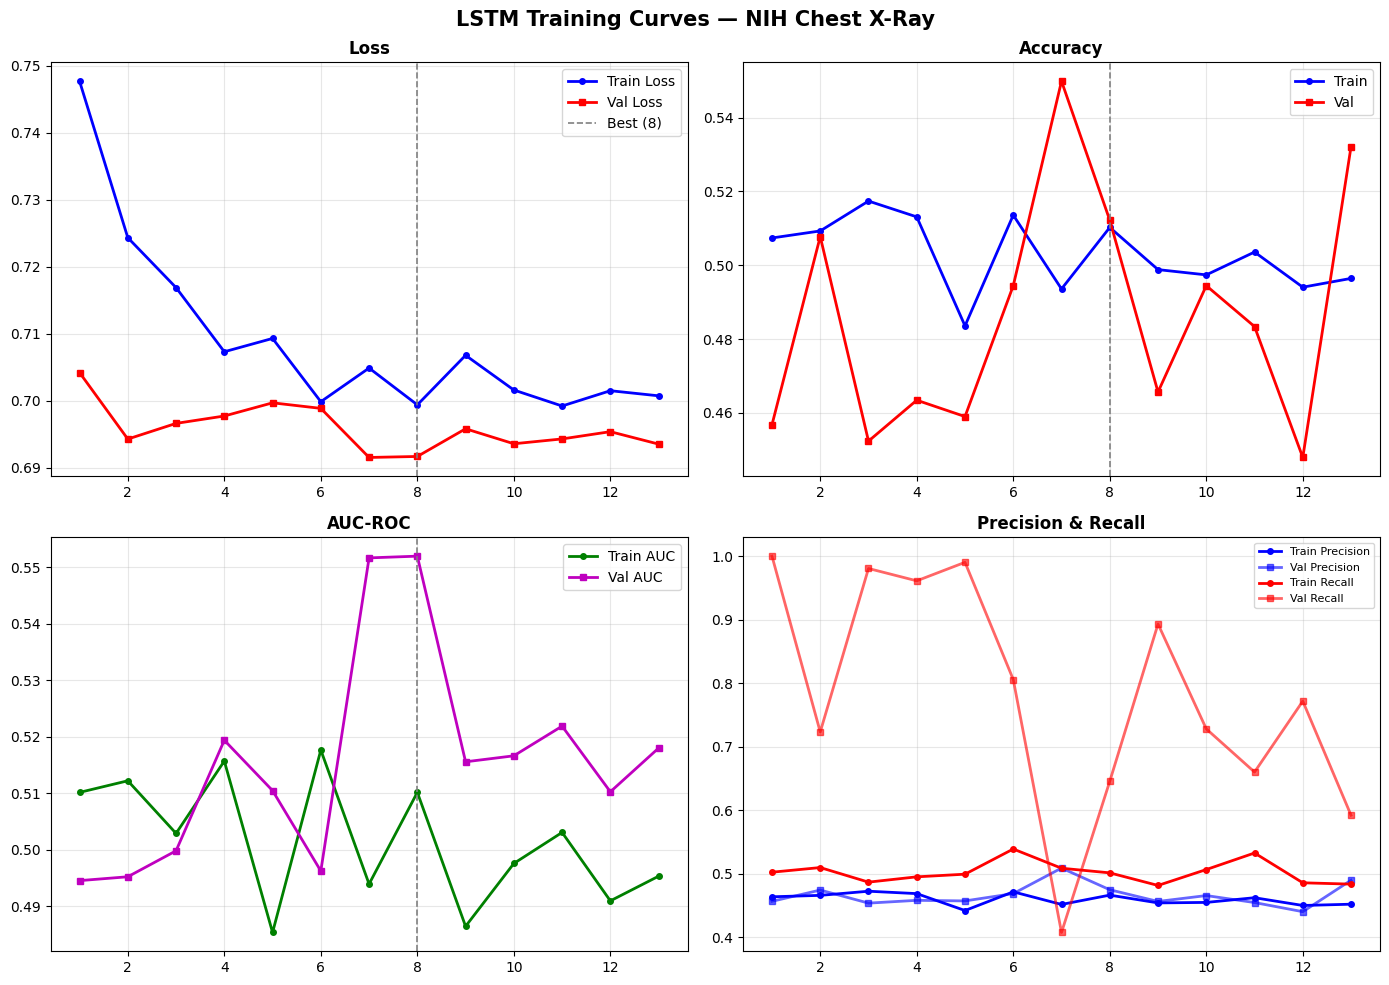

Saved → lstm_training_curves.png


In [10]:
h = lstm_history.history
ep = range(1, len(h['loss'])+1)
best_ep = np.argmax(h['val_auc'])+1

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('LSTM Training Curves — NIH Chest X-Ray', fontsize=15, fontweight='bold')

axes[0,0].plot(ep, h['loss'],     'b-o', lw=2, ms=4, label='Train Loss')
axes[0,0].plot(ep, h['val_loss'], 'r-s', lw=2, ms=4, label='Val Loss')
axes[0,0].axvline(best_ep, color='gray', ls='--', lw=1.2, label=f'Best ({best_ep})')
axes[0,0].set_title('Loss', fontweight='bold'); axes[0,0].legend(); axes[0,0].grid(alpha=0.3)

axes[0,1].plot(ep, h['accuracy'],     'b-o', lw=2, ms=4, label='Train')
axes[0,1].plot(ep, h['val_accuracy'], 'r-s', lw=2, ms=4, label='Val')
axes[0,1].axvline(best_ep, color='gray', ls='--', lw=1.2)
axes[0,1].set_title('Accuracy', fontweight='bold'); axes[0,1].legend(); axes[0,1].grid(alpha=0.3)

axes[1,0].plot(ep, h['auc'],     'g-o', lw=2, ms=4, label='Train AUC')
axes[1,0].plot(ep, h['val_auc'], 'm-s', lw=2, ms=4, label='Val AUC')
axes[1,0].axvline(best_ep, color='gray', ls='--', lw=1.2)
axes[1,0].set_title('AUC-ROC', fontweight='bold'); axes[1,0].legend(); axes[1,0].grid(alpha=0.3)

axes[1,1].plot(ep, h['precision'],     'b-o', lw=2, ms=4, label='Train Precision')
axes[1,1].plot(ep, h['val_precision'], 'b-s', lw=2, ms=4, label='Val Precision', alpha=0.6)
axes[1,1].plot(ep, h['recall'],        'r-o', lw=2, ms=4, label='Train Recall')
axes[1,1].plot(ep, h['val_recall'],    'r-s', lw=2, ms=4, label='Val Recall', alpha=0.6)
axes[1,1].set_title('Precision & Recall', fontweight='bold')
axes[1,1].legend(fontsize=8); axes[1,1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('lstm_training_curves.png', dpi=180, bbox_inches='tight')
plt.show()
print('Saved → lstm_training_curves.png')

## 📊 Cell 11: LSTM Evaluation on Test Set

W0000 00:00:1778561474.522027   91010 cpu_allocator_impl.cc:82] Allocation of 29491200 exceeds 10% of free system memory.


LSTM TEST RESULTS
Accuracy : 0.4933  (Phase 2 CNN: 0.614)
F1-Score : 0.5230  (Phase 2 CNN: 0.621)
AUC-ROC  : 0.5086  (Phase 2 CNN: 0.648)
              precision    recall  f1-score   support

      Normal       0.54      0.40      0.46       244
    Diseased       0.46      0.61      0.52       206

    accuracy                           0.49       450
   macro avg       0.50      0.50      0.49       450
weighted avg       0.51      0.49      0.49       450



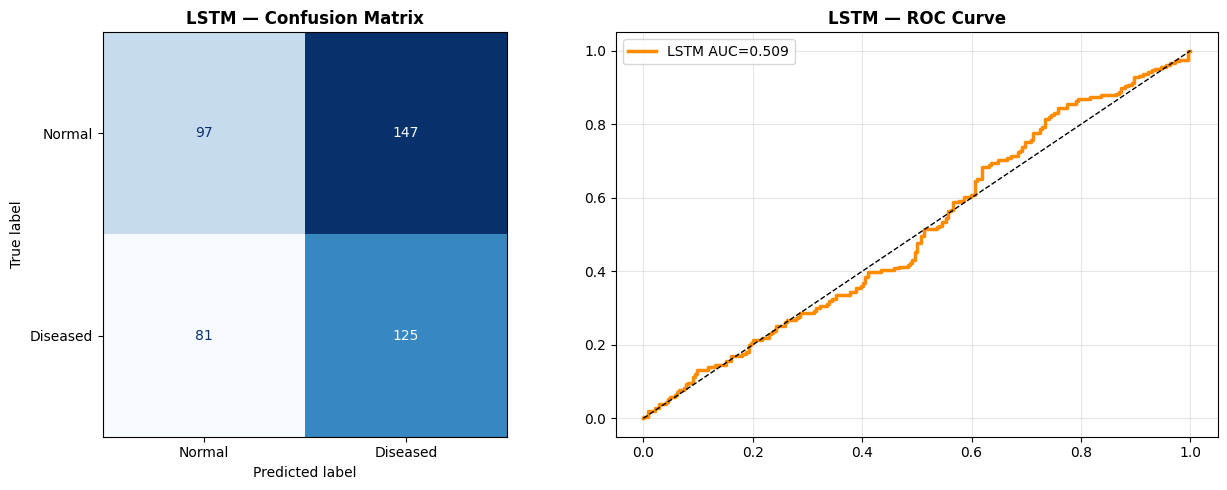

In [11]:
y_prob_lstm = lstm_model.predict(X_test_lstm, batch_size=BATCH_SIZE, verbose=0).ravel()
y_pred_lstm = (y_prob_lstm >= 0.5).astype(int)

acc_lstm = accuracy_score(y_test, y_pred_lstm)
f1_lstm  = f1_score(y_test, y_pred_lstm)
fpr_lstm, tpr_lstm, _ = roc_curve(y_test, y_prob_lstm)
auc_lstm = auc(fpr_lstm, tpr_lstm)

print('='*60)
print('LSTM TEST RESULTS')
print('='*60)
print(f'Accuracy : {acc_lstm:.4f}  (Phase 2 CNN: {PHASE2_CNN_ACC})')
print(f'F1-Score : {f1_lstm:.4f}  (Phase 2 CNN: {PHASE2_CNN_F1})')
print(f'AUC-ROC  : {auc_lstm:.4f}  (Phase 2 CNN: {PHASE2_CNN_AUC})')
print('='*60)
print(classification_report(y_test, y_pred_lstm, target_names=['Normal','Diseased']))

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
ConfusionMatrixDisplay(
    confusion_matrix(y_test, y_pred_lstm),
    display_labels=['Normal','Diseased']
).plot(ax=axes[0], colorbar=False, cmap='Blues')
axes[0].set_title('LSTM — Confusion Matrix', fontweight='bold')

axes[1].plot(fpr_lstm, tpr_lstm, color='darkorange', lw=2.5, label=f'LSTM AUC={auc_lstm:.3f}')
axes[1].plot([0,1],[0,1],'k--',lw=1)
axes[1].set_title('LSTM — ROC Curve', fontweight='bold')
axes[1].legend(); axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('lstm_evaluation.png', dpi=180, bbox_inches='tight')
plt.show()

---
# 🤖 Part 2: Vision Transformer (ViT) — Fine-Tuned
### Strategy: Fine-tune google/vit-base-patch16-224 pretrained on ImageNet using PyTorch + timm
---

## 🧠 Cell 12: PyTorch Dataset for ViT

In [12]:
class ChestXRayDataset(Dataset):
    """PyTorch Dataset for NIH Chest X-Ray images."""

    def __init__(self, dataframe, transform=None):
        self.df        = dataframe.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img = Image.open(row['img_path']).convert('RGB')  # ViT needs RGB
        if self.transform:
            img = self.transform(img)
        label = torch.tensor(row['label'], dtype=torch.float32)
        return img, label


# ViT transforms — ImageNet normalization (ViT was pretrained on ImageNet)
vit_train_transform = transforms.Compose([
    transforms.Resize((VIT_SIZE, VIT_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(8),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225]),
])

vit_val_transform = transforms.Compose([
    transforms.Resize((VIT_SIZE, VIT_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225]),
])

train_dataset = ChestXRayDataset(train_df, transform=vit_train_transform)
val_dataset   = ChestXRayDataset(val_df,   transform=vit_val_transform)
test_dataset  = ChestXRayDataset(test_df,  transform=vit_val_transform)

train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True,  num_workers=2)
val_loader   = DataLoader(val_dataset,   batch_size=16, shuffle=False, num_workers=2)
test_loader  = DataLoader(test_dataset,  batch_size=16, shuffle=False, num_workers=2)

print(f'Train batches: {len(train_loader)} | Val batches: {len(val_loader)} | Test batches: {len(test_loader)}')

Train batches: 132 | Val batches: 29 | Test batches: 29


## 🧠 Cell 13: Build Vision Transformer (ViT) — Fine-Tune

In [20]:
class ViTClassifier(nn.Module):
    """Fine-tuned ViT-Base/16 for binary chest X-ray classification."""

    def __init__(self, num_classes=1, freeze_layers=True):
        super(ViTClassifier, self).__init__()

        # Load pretrained ViT-Base/16 from timm
        self.vit = timm.create_model(
            'vit_base_patch16_224',
            pretrained=True,
            num_classes=0   # Remove classification head — we add our own
        )
        
        for block in self.vit.blocks:
            block.attn.fused_attn = False

        # Freeze all layers except last 4 transformer blocks
        if freeze_layers:
            for name, param in self.vit.named_parameters():
                param.requires_grad = False
            # Unfreeze last 4 blocks + norm layer
            for name, param in self.vit.named_parameters():
                if any(f'blocks.{i}' in name for i in [8, 9, 10, 11]):
                    param.requires_grad = True
                if 'norm' in name:
                    param.requires_grad = True

        embed_dim = self.vit.num_features  # 768 for ViT-Base

        # Custom classification head
        self.classifier = nn.Sequential(
            nn.LayerNorm(embed_dim),
            nn.Linear(embed_dim, 256),
            nn.GELU(),
            nn.Dropout(0.4),
            nn.Linear(256, 64),
            nn.GELU(),
            nn.Dropout(0.2),
            nn.Linear(64, num_classes)
        )

    def forward(self, x):
        features = self.vit(x)        # (batch, 768)
        out = self.classifier(features)
        return out

    def get_attention_maps(self, x):
        """Extract attention maps from the last transformer block."""
        # Register hook to capture attention weights
        attention_maps = []

        def hook_fn(module, input, output):
            # output shape: (batch, heads, seq_len, seq_len)
            attention_maps.append(output.detach())

        # Hook into last attention block
        hook = self.vit.blocks[-1].attn.attn_drop.register_forward_hook(hook_fn)

        with torch.no_grad():
            _ = self.forward(x)

        hook.remove()
        return attention_maps[0] if attention_maps else None


vit_model = ViTClassifier(num_classes=1, freeze_layers=True).to(DEVICE)

# Count trainable parameters
total_params     = sum(p.numel() for p in vit_model.parameters())
trainable_params = sum(p.numel() for p in vit_model.parameters() if p.requires_grad)
print(f'Total parameters     : {total_params:,}')
print(f'Trainable parameters : {trainable_params:,} ({100*trainable_params/total_params:.1f}%)')
print(f'Frozen parameters    : {total_params-trainable_params:,}')

Total parameters     : 86,013,569
Trainable parameters : 28,592,513 (33.2%)
Frozen parameters    : 57,421,056


## 🧠 Cell 14: Training Loop for ViT

In [14]:
from sklearn.metrics import roc_auc_score

def train_vit_epoch(model, loader, criterion, optimizer, device):
    model.train()
    total_loss, all_preds, all_labels = 0, [], []

    for imgs, labels in loader:
        imgs, labels = imgs.to(device), labels.to(device).unsqueeze(1)
        optimizer.zero_grad()
        outputs = model(imgs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * imgs.size(0)
        probs = torch.sigmoid(outputs).cpu().detach().numpy().ravel()
        all_preds.extend(probs)
        all_labels.extend(labels.cpu().numpy().ravel())

    avg_loss = total_loss / len(loader.dataset)
    acc = accuracy_score(np.array(all_labels), (np.array(all_preds) >= 0.5).astype(int))
    auc_score = roc_auc_score(all_labels, all_preds)
    return avg_loss, acc, auc_score


@torch.no_grad()
def eval_vit_epoch(model, loader, criterion, device):
    model.eval()
    total_loss, all_preds, all_labels = 0, [], []

    for imgs, labels in loader:
        imgs, labels = imgs.to(device), labels.to(device).unsqueeze(1)
        outputs = model(imgs)
        loss = criterion(outputs, labels)

        total_loss += loss.item() * imgs.size(0)
        probs = torch.sigmoid(outputs).cpu().numpy().ravel()
        all_preds.extend(probs)
        all_labels.extend(labels.cpu().numpy().ravel())

    avg_loss = total_loss / len(loader.dataset)
    acc = accuracy_score(np.array(all_labels), (np.array(all_preds) >= 0.5).astype(int))
    auc_score = roc_auc_score(all_labels, all_preds)
    return avg_loss, acc, auc_score, np.array(all_preds), np.array(all_labels)


# Class weights for imbalanced data
pos_weight = torch.tensor([class_weight_dict[1] / class_weight_dict[0]]).to(DEVICE)
criterion  = nn.BCEWithLogitsLoss(pos_weight=pos_weight)

optimizer_vit = optim.AdamW(
    filter(lambda p: p.requires_grad, vit_model.parameters()),
    lr=1e-4, weight_decay=0.01
)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer_vit, T_max=EPOCHS_VIT, eta_min=1e-6)

print('Training Vision Transformer (ViT)...')
print('='*70)

vit_train_losses, vit_val_losses   = [], []
vit_train_accs,   vit_val_accs     = [], []
vit_train_aucs,   vit_val_aucs     = [], []
best_val_auc = 0
best_vit_path = 'best_vit.pth'

for epoch in range(1, EPOCHS_VIT + 1):
    train_loss, train_acc, train_auc = train_vit_epoch(vit_model, train_loader, criterion, optimizer_vit, DEVICE)
    val_loss,   val_acc,   val_auc, _, _ = eval_vit_epoch(vit_model, val_loader, criterion, DEVICE)
    scheduler.step()

    vit_train_losses.append(train_loss); vit_val_losses.append(val_loss)
    vit_train_accs.append(train_acc);   vit_val_accs.append(val_acc)
    vit_train_aucs.append(train_auc);   vit_val_aucs.append(val_auc)

    if val_auc > best_val_auc:
        best_val_auc = val_auc
        torch.save(vit_model.state_dict(), best_vit_path)
        saved = '✅ saved'
    else:
        saved = ''

    print(f'Epoch {epoch:2d}/{EPOCHS_VIT} | '
          f'Train Loss={train_loss:.4f} Acc={train_acc:.4f} AUC={train_auc:.4f} | '
          f'Val Loss={val_loss:.4f} Acc={val_acc:.4f} AUC={val_auc:.4f} {saved}')

print(f'\nBest Val AUC: {best_val_auc:.4f}')

Training Vision Transformer (ViT)...
Epoch  1/10 | Train Loss=0.7369 Acc=0.5765 AUC=0.5997 | Val Loss=0.7084 Acc=0.6009 AUC=0.7029 ✅ saved
Epoch  2/10 | Train Loss=0.6914 Acc=0.6660 AUC=0.6922 | Val Loss=0.6702 Acc=0.6696 AUC=0.7319 ✅ saved
Epoch  3/10 | Train Loss=0.6821 Acc=0.6641 AUC=0.7067 | Val Loss=0.6441 Acc=0.6829 AUC=0.7534 ✅ saved
Epoch  4/10 | Train Loss=0.6607 Acc=0.6813 AUC=0.7311 | Val Loss=0.6631 Acc=0.6918 AUC=0.7626 ✅ saved
Epoch  5/10 | Train Loss=0.6486 Acc=0.6960 AUC=0.7469 | Val Loss=0.6785 Acc=0.6053 AUC=0.7764 ✅ saved
Epoch  6/10 | Train Loss=0.6383 Acc=0.6946 AUC=0.7561 | Val Loss=0.6438 Acc=0.6763 AUC=0.7646 
Epoch  7/10 | Train Loss=0.6130 Acc=0.7208 AUC=0.7817 | Val Loss=0.6318 Acc=0.7095 AUC=0.7689 
Epoch  8/10 | Train Loss=0.5935 Acc=0.7237 AUC=0.7992 | Val Loss=0.6462 Acc=0.6940 AUC=0.7595 
Epoch  9/10 | Train Loss=0.5716 Acc=0.7485 AUC=0.8173 | Val Loss=0.6494 Acc=0.7118 AUC=0.7635 
Epoch 10/10 | Train Loss=0.5553 Acc=0.7566 AUC=0.8289 | Val Loss=0.6554 A

## 📈 Cell 15: ViT Training Curves

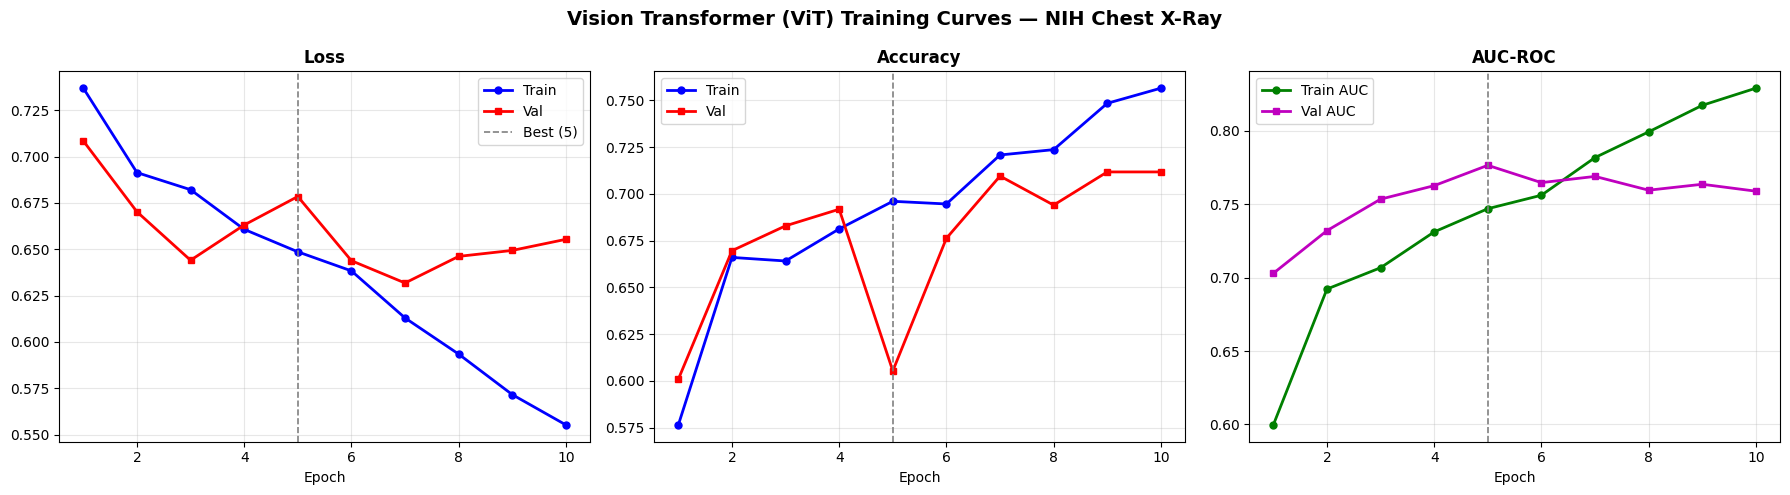

Saved → vit_training_curves.png


In [15]:
ep = range(1, EPOCHS_VIT + 1)
best_ep_vit = np.argmax(vit_val_aucs) + 1

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Vision Transformer (ViT) Training Curves — NIH Chest X-Ray', fontsize=14, fontweight='bold')

axes[0].plot(ep, vit_train_losses, 'b-o', lw=2, ms=5, label='Train')
axes[0].plot(ep, vit_val_losses,   'r-s', lw=2, ms=5, label='Val')
axes[0].axvline(best_ep_vit, color='gray', ls='--', lw=1.2, label=f'Best ({best_ep_vit})')
axes[0].set_title('Loss', fontweight='bold'); axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].plot(ep, vit_train_accs, 'b-o', lw=2, ms=5, label='Train')
axes[1].plot(ep, vit_val_accs,   'r-s', lw=2, ms=5, label='Val')
axes[1].axvline(best_ep_vit, color='gray', ls='--', lw=1.2)
axes[1].set_title('Accuracy', fontweight='bold'); axes[1].legend(); axes[1].grid(alpha=0.3)

axes[2].plot(ep, vit_train_aucs, 'g-o', lw=2, ms=5, label='Train AUC')
axes[2].plot(ep, vit_val_aucs,   'm-s', lw=2, ms=5, label='Val AUC')
axes[2].axvline(best_ep_vit, color='gray', ls='--', lw=1.2)
axes[2].set_title('AUC-ROC', fontweight='bold'); axes[2].legend(); axes[2].grid(alpha=0.3)

for ax in axes: ax.set_xlabel('Epoch')

plt.tight_layout()
plt.savefig('vit_training_curves.png', dpi=180, bbox_inches='tight')
plt.show()
print('Saved → vit_training_curves.png')

## 📊 Cell 16: ViT Evaluation on Test Set

VISION TRANSFORMER (ViT) TEST RESULTS
Accuracy : 0.5467  (Phase 2 CNN: 0.614)
F1-Score : 0.6542  (Phase 2 CNN: 0.621)
AUC-ROC  : 0.6772  (Phase 2 CNN: 0.648)
              precision    recall  f1-score   support

      Normal       0.80      0.22      0.34       244
    Diseased       0.50      0.94      0.65       206

    accuracy                           0.55       450
   macro avg       0.65      0.58      0.50       450
weighted avg       0.67      0.55      0.48       450



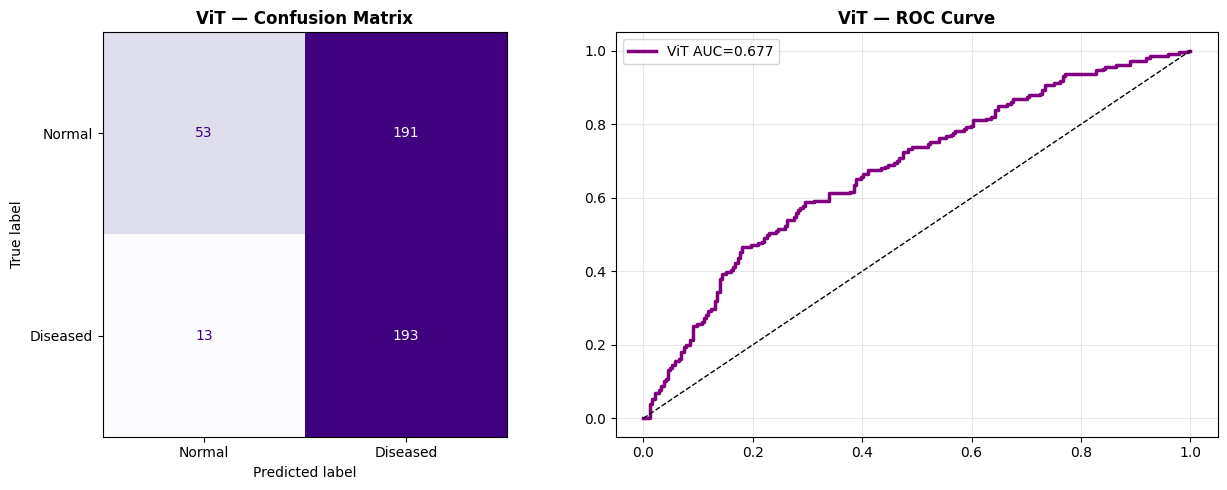

In [16]:
# Load best checkpoint
vit_model.load_state_dict(torch.load(best_vit_path, map_location=DEVICE))

_, _, _, y_prob_vit, y_true_vit = eval_vit_epoch(vit_model, test_loader, criterion, DEVICE)
y_pred_vit = (y_prob_vit >= 0.5).astype(int)

acc_vit = accuracy_score(y_true_vit, y_pred_vit)
f1_vit  = f1_score(y_true_vit, y_pred_vit)
fpr_vit, tpr_vit, _ = roc_curve(y_true_vit, y_prob_vit)
auc_vit = auc(fpr_vit, tpr_vit)

print('='*60)
print('VISION TRANSFORMER (ViT) TEST RESULTS')
print('='*60)
print(f'Accuracy : {acc_vit:.4f}  (Phase 2 CNN: {PHASE2_CNN_ACC})')
print(f'F1-Score : {f1_vit:.4f}  (Phase 2 CNN: {PHASE2_CNN_F1})')
print(f'AUC-ROC  : {auc_vit:.4f}  (Phase 2 CNN: {PHASE2_CNN_AUC})')
print('='*60)
print(classification_report(y_true_vit, y_pred_vit, target_names=['Normal','Diseased']))

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
ConfusionMatrixDisplay(
    confusion_matrix(y_true_vit, y_pred_vit),
    display_labels=['Normal','Diseased']
).plot(ax=axes[0], colorbar=False, cmap='Purples')
axes[0].set_title('ViT — Confusion Matrix', fontweight='bold')

axes[1].plot(fpr_vit, tpr_vit, color='purple', lw=2.5, label=f'ViT AUC={auc_vit:.3f}')
axes[1].plot([0,1],[0,1],'k--',lw=1)
axes[1].set_title('ViT — ROC Curve', fontweight='bold')
axes[1].legend(); axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('vit_evaluation.png', dpi=180, bbox_inches='tight')
plt.show()

---
# 🔍 Part 3: Attention Visualization
### ViT Attention Heatmaps — What does the model focus on in chest X-rays?
---

## 🎨 Cell 17: ViT Attention Map Extractor

In [21]:
def get_vit_attention_map(model, img_tensor, patch_size=16, img_size=224):
    """
    Extract and process attention maps from ViT's last transformer block.

    Args:
        model      : trained ViTClassifier
        img_tensor : (1, 3, 224, 224) tensor
        patch_size : patch size (16 for ViT-B/16)
        img_size   : input image size

    Returns:
        attention_map : (img_size, img_size) numpy array
    """
    model.eval()
    attention_weights = []

    def hook_fn(module, input, output):
        # output: (batch, heads, seq_len, seq_len)
        attention_weights.append(output.detach().cpu())

    # Register hook on last block's attention
    hook = model.vit.blocks[-1].attn.attn_drop.register_forward_hook(hook_fn)

    with torch.no_grad():
        _ = model(img_tensor.to(DEVICE))

    hook.remove()

    if not attention_weights:
        print("⚠️ Hook captured nothing — fused_attn may still be enabled.")
        return None

    attn = attention_weights[0]  # (1, heads, seq+1, seq+1)
    attn = attn[0]               # (heads, seq+1, seq+1)

    # CLS token attention to all patches (index 0 = CLS)
    cls_attn = attn[:, 0, 1:]   # (heads, num_patches)

    # Average across heads
    avg_attn = cls_attn.mean(0)  # (num_patches,)

    # Reshape to grid
    num_patches_side = img_size // patch_size  # 14 for 224/16
    avg_attn = avg_attn.reshape(num_patches_side, num_patches_side).numpy()

    # Normalize to [0, 1]
    avg_attn = (avg_attn - avg_attn.min()) / (avg_attn.max() - avg_attn.min() + 1e-8)

    # Upsample to original image size
    attn_resized = cv2.resize(avg_attn, (img_size, img_size), interpolation=cv2.INTER_CUBIC)

    return attn_resized


def visualize_attention_overlay(original_img_np, attn_map, title='Attention Map', ax=None):
    """
    Overlay attention heatmap on original chest X-ray.
    """
    if ax is None:
        fig, ax = plt.subplots(1, 1, figsize=(5, 5))

    # Convert attention to heatmap
    heatmap = cm.jet(attn_map)[:, :, :3]  # RGB heatmap (H, W, 3)

    # Overlay: 60% original + 40% heatmap
    overlay = 0.6 * original_img_np + 0.4 * heatmap
    overlay = np.clip(overlay, 0, 1)

    ax.imshow(overlay)
    ax.set_title(title, fontsize=9, fontweight='bold')
    ax.axis('off')


print('✅ Attention extraction functions defined.')

✅ Attention extraction functions defined.


## 🎨 Cell 18: Generate Attention Heatmaps — Normal vs Diseased

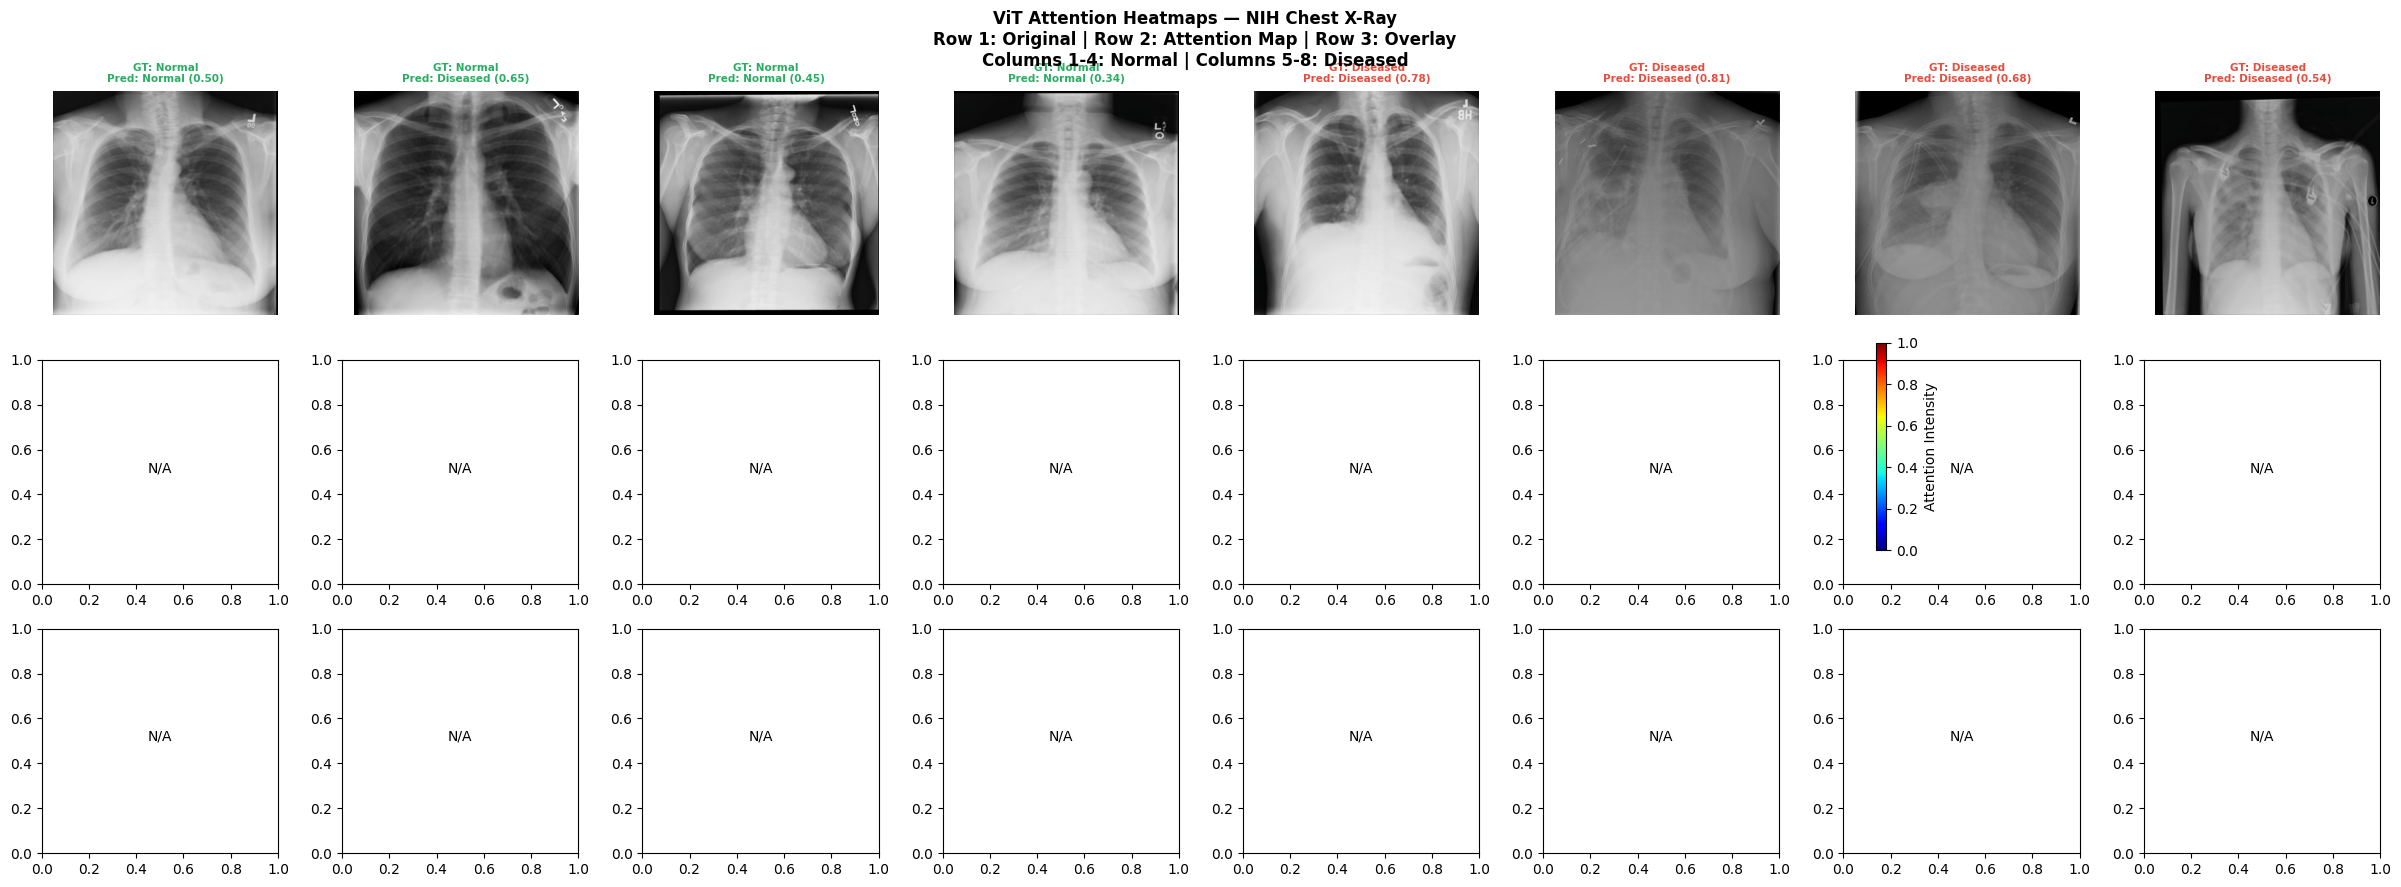

Saved → vit_attention_heatmaps.png


In [18]:
# Pick 4 Normal + 4 Diseased test images for visualization
normal_indices   = np.where(y_true_vit == 0)[0][:4]
diseased_indices = np.where(y_true_vit == 1)[0][:4]

selected_indices = list(normal_indices) + list(diseased_indices)
selected_labels  = ['Normal'] * 4 + ['Diseased'] * 4

# Denormalization transform
mean = np.array([0.485, 0.456, 0.406])
std  = np.array([0.229, 0.224, 0.225])

fig, axes = plt.subplots(3, 8, figsize=(24, 9))
fig.suptitle(
    'ViT Attention Heatmaps — NIH Chest X-Ray\n'
    'Row 1: Original | Row 2: Attention Map | Row 3: Overlay\n'
    'Columns 1-4: Normal | Columns 5-8: Diseased',
    fontsize=12, fontweight='bold'
)

for col, (idx, label) in enumerate(zip(selected_indices, selected_labels)):
    # Get image tensor from dataset
    img_tensor, true_label = test_dataset[idx]
    img_tensor_batch = img_tensor.unsqueeze(0)  # (1, 3, 224, 224)

    # Denormalize for display
    img_display = img_tensor.numpy().transpose(1, 2, 0)  # (H, W, 3)
    img_display = std * img_display + mean
    img_display = np.clip(img_display, 0, 1)

    # Get prediction
    vit_model.eval()
    with torch.no_grad():
        logit = vit_model(img_tensor_batch.to(DEVICE))
        prob  = torch.sigmoid(logit).item()
        pred  = 'Diseased' if prob >= 0.5 else 'Normal'

    # Get attention map
    attn_map = get_vit_attention_map(vit_model, img_tensor_batch)

    color = '#27AE60' if label == 'Normal' else '#E74C3C'

    # Row 1: Original image
    axes[0, col].imshow(img_display)
    axes[0, col].set_title(f'GT: {label}\nPred: {pred} ({prob:.2f})',
                            fontsize=7.5, color=color, fontweight='bold')
    axes[0, col].axis('off')

    if attn_map is not None:
        # Row 2: Raw attention map
        axes[1, col].imshow(attn_map, cmap='jet')
        axes[1, col].set_title('Attention Map', fontsize=7.5)
        axes[1, col].axis('off')

        # Row 3: Overlay
        visualize_attention_overlay(img_display, attn_map,
                                    title='Overlay', ax=axes[2, col])
    else:
        axes[1, col].text(0.5, 0.5, 'N/A', ha='center')
        axes[2, col].text(0.5, 0.5, 'N/A', ha='center')

# Add colorbar for attention scale
sm = plt.cm.ScalarMappable(cmap='jet', norm=plt.Normalize(vmin=0, vmax=1))
sm.set_array([])
fig.colorbar(sm, ax=axes.ravel().tolist(), shrink=0.3, pad=0.01, label='Attention Intensity')

plt.tight_layout()
plt.savefig('vit_attention_heatmaps.png', dpi=180, bbox_inches='tight')
plt.show()
print('Saved → vit_attention_heatmaps.png')

## 🎨 Cell 19: Attention Analysis — Head-by-Head Visualization

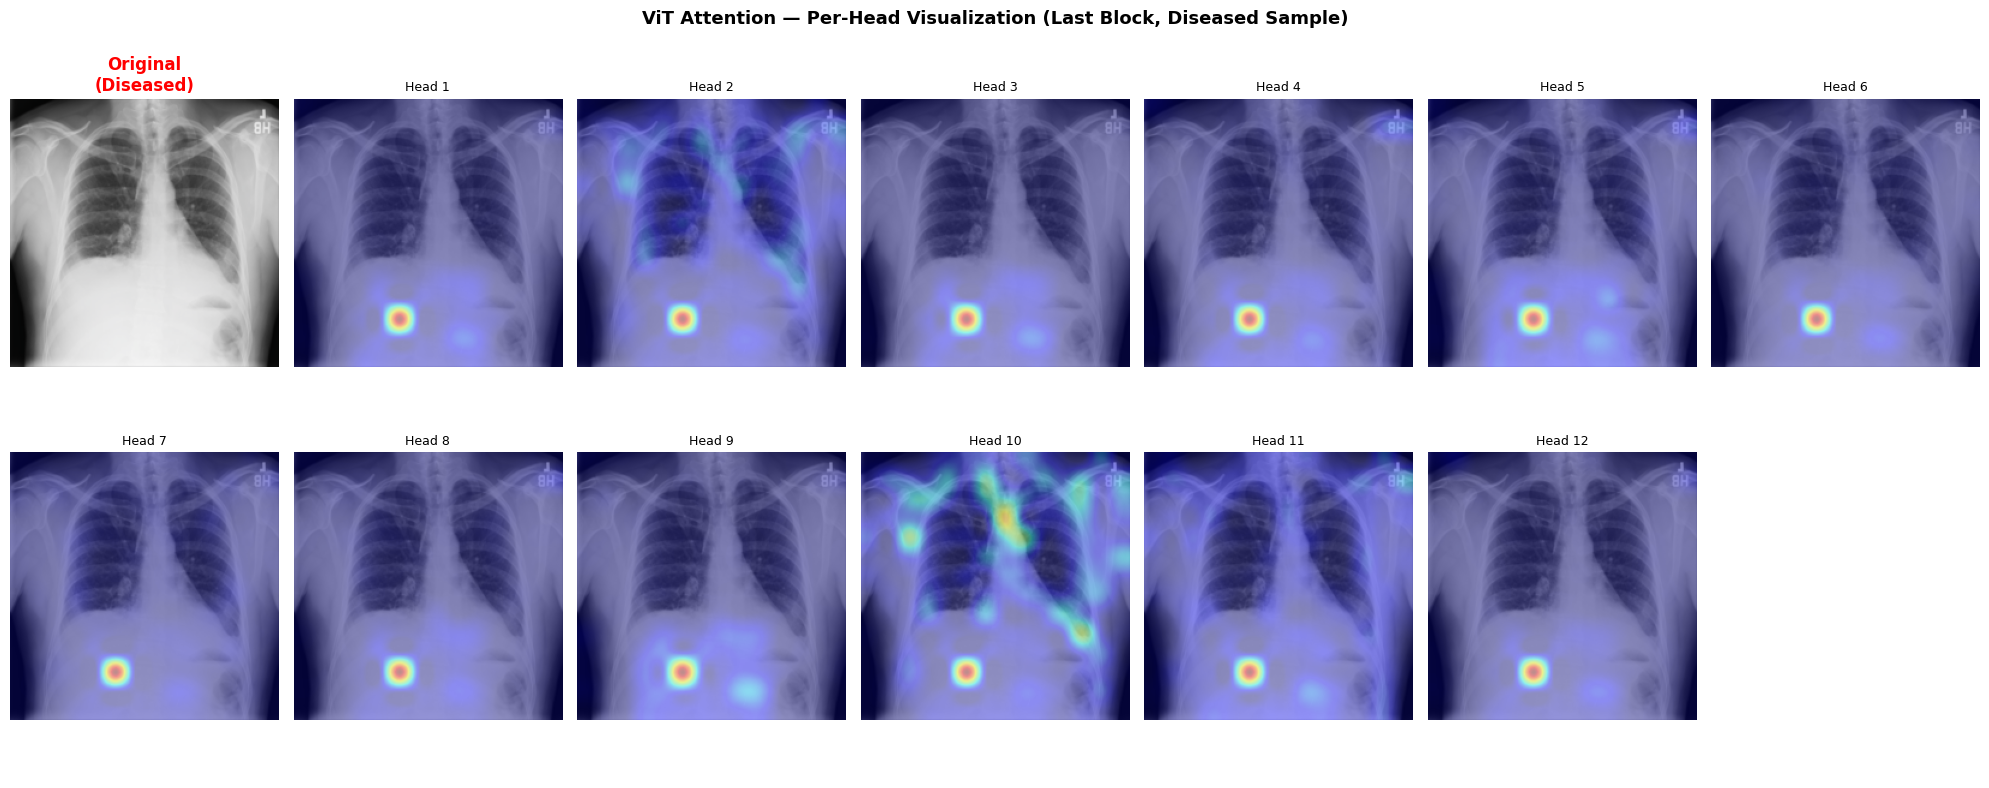

Saved → vit_attention_heads.png


In [22]:
def get_per_head_attention(model, img_tensor, patch_size=16, img_size=224):
    """Extract per-head attention maps from the last transformer block."""
    model.eval()
    attention_weights = []

    def hook_fn(module, input, output):
        attention_weights.append(output.detach().cpu())

    hook = model.vit.blocks[-1].attn.attn_drop.register_forward_hook(hook_fn)

    with torch.no_grad():
        _ = model(img_tensor.to(DEVICE))

    hook.remove()

    if not attention_weights:
        print("⚠️ No attention weights captured.")
        return []

    attn = attention_weights[0][0]     # (heads, seq+1, seq+1)
    num_heads = attn.shape[0]
    num_patches_side = img_size // patch_size

    head_maps = []
    for h in range(num_heads):
        cls_attn   = attn[h, 0, 1:].numpy()   # (num_patches,)
        attn_grid  = cls_attn.reshape(num_patches_side, num_patches_side)
        attn_grid  = (attn_grid - attn_grid.min()) / (attn_grid.max() - attn_grid.min() + 1e-8)
        attn_resized = cv2.resize(attn_grid, (img_size, img_size), interpolation=cv2.INTER_CUBIC)
        head_maps.append(attn_resized)

    return head_maps


# ── Visualize all heads for one Diseased sample ──
sample_idx = diseased_indices[0]
img_tensor, _ = test_dataset[sample_idx]
img_tensor_batch = img_tensor.unsqueeze(0)

img_display = img_tensor.numpy().transpose(1, 2, 0)
img_display = std * img_display + mean
img_display = np.clip(img_display, 0, 1)

head_maps = get_per_head_attention(vit_model, img_tensor_batch)

if not head_maps:
    print("⚠️ Skipping head visualization — no attention captured.")
else:
    num_heads = len(head_maps)
    ncols = (num_heads + 2) // 2
    fig, axes = plt.subplots(2, ncols, figsize=(20, 8))
    axes = axes.ravel()

    axes[0].imshow(img_display)
    axes[0].set_title('Original\n(Diseased)', fontweight='bold', color='red')
    axes[0].axis('off')

    for h, hmap in enumerate(head_maps):
        overlay = 0.6 * img_display + 0.4 * cm.jet(hmap)[:, :, :3]
        overlay = np.clip(overlay, 0, 1)
        axes[h+1].imshow(overlay)
        axes[h+1].set_title(f'Head {h+1}', fontsize=9)
        axes[h+1].axis('off')

    for i in range(num_heads + 1, len(axes)):
        axes[i].axis('off')

    fig.suptitle('ViT Attention — Per-Head Visualization (Last Block, Diseased Sample)',
                 fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.savefig('vit_attention_heads.png', dpi=180, bbox_inches='tight')
    plt.show()
    print('Saved → vit_attention_heads.png')


---
# 🏆 Part 4: Final Comparison — Phase 2 vs Phase 3
---

## 📊 Cell 20: Full Comparison Table

In [23]:
comparison_df = pd.DataFrame({
    'Phase': [
        'Phase 2', 'Phase 2', 'Phase 2',
        'Phase 3', 'Phase 3'
    ],
    'Model': [
        'CNN (scratch)',
        'TL: VGG16 (Best Phase 2)',
        'Autoencoder',
        'BiLSTM (rows as sequences)',
        'ViT-Base/16 (fine-tuned)'
    ],
    'Type': [
        'CNN', 'Transfer Learning', 'Unsupervised',
        'Recurrent (LSTM)', 'Transformer'
    ],
    'Accuracy': [
        PHASE2_CNN_ACC, PHASE2_VGG_ACC, 0.550,
        round(acc_lstm, 4), round(acc_vit, 4)
    ],
    'F1-Score': [
        PHASE2_CNN_F1, PHASE2_VGG_F1, 0.130,
        round(f1_lstm, 4), round(f1_vit, 4)
    ],
    'AUC-ROC': [
        PHASE2_CNN_AUC, PHASE2_VGG_AUC, 0.480,
        round(auc_lstm, 4), round(auc_vit, 4)
    ]
})

print('='*80)
print('PHASE 2 vs PHASE 3 — FULL COMPARISON TABLE')
print('='*80)
display(comparison_df)

# Highlight best
best_row = comparison_df.loc[comparison_df['AUC-ROC'].idxmax()]
print(f'\n🏆 Best model overall: {best_row["Model"]}')
print(f'   Accuracy={best_row["Accuracy"]:.4f} | F1={best_row["F1-Score"]:.4f} | AUC={best_row["AUC-ROC"]:.4f}')

PHASE 2 vs PHASE 3 — FULL COMPARISON TABLE


,Phase,Model,Type,Accuracy,F1-Score,AUC-ROC
0,Phase 2,CNN (scratch),CNN,0.6140,0.6210,0.6480
1,Phase 2,TL: VGG16 (Best Phase 2),Transfer Learning,0.6670,0.6560,0.7050
2,Phase 2,Autoencoder,Unsupervised,0.5500,0.1300,0.4800
3,Phase 3,BiLSTM (rows as sequences),Recurrent (LSTM),0.4933,0.5230,0.5086
4,Phase 3,ViT-Base/16 (fine-tuned),Transformer,0.5467,0.6542,0.6772



🏆 Best model overall: TL: VGG16 (Best Phase 2)
   Accuracy=0.6670 | F1=0.6560 | AUC=0.7050


## 📊 Cell 21: Final Comparison Chart

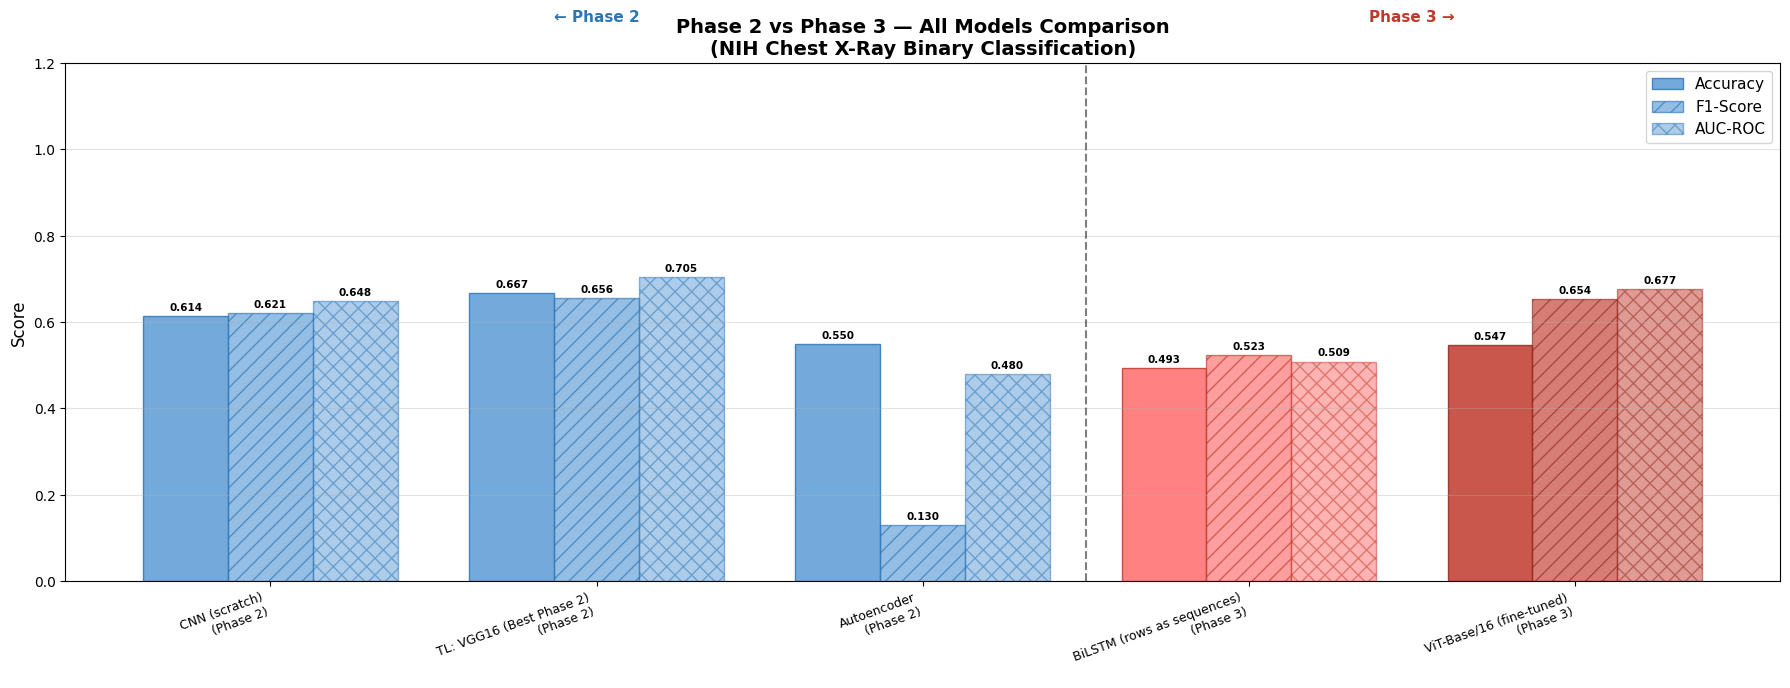

Saved → phase3_final_comparison.png


In [24]:
models_labels = comparison_df['Model'].tolist()
phases        = comparison_df['Phase'].tolist()
colors = [
    '#5B9BD5', '#5B9BD5', '#5B9BD5',   # Phase 2 — blue family
    '#FF6B6B', '#C0392B'               # Phase 3 — red family
]
edge_colors = [
    '#2E75B6', '#2E75B6', '#2E75B6',
    '#C0392B', '#922B21'
]

x  = np.arange(len(models_labels))
w  = 0.26

fig, ax = plt.subplots(figsize=(18, 7))

bars_acc = ax.bar(x - w, comparison_df['Accuracy'], w,
                  label='Accuracy', color=colors, edgecolor=edge_colors, alpha=0.85)
bars_f1  = ax.bar(x,     comparison_df['F1-Score'], w,
                  label='F1-Score', color=colors, edgecolor=edge_colors, alpha=0.65, hatch='//')
bars_auc = ax.bar(x + w, comparison_df['AUC-ROC'],  w,
                  label='AUC-ROC',  color=colors, edgecolor=edge_colors, alpha=0.5,  hatch='xx')

# Value labels
for bar in list(bars_acc) + list(bars_f1) + list(bars_auc):
    h = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, h + 0.008, f'{h:.3f}',
            ha='center', va='bottom', fontsize=7.5, fontweight='bold')

# Phase separator line
ax.axvline(x=2.5, color='black', lw=1.5, ls='--', alpha=0.5)
ax.text(1.0, 1.08, '← Phase 2', ha='center', fontsize=11, color='#2E75B6', fontweight='bold',
        transform=ax.get_xaxis_transform())
ax.text(3.5, 1.08, 'Phase 3 →', ha='center', fontsize=11, color='#C0392B', fontweight='bold',
        transform=ax.get_xaxis_transform())

ax.set_xticks(x)
ax.set_xticklabels(
    [f'{m}\n({p})' for m, p in zip(models_labels, phases)],
    rotation=20, ha='right', fontsize=9
)
ax.set_ylim(0, 1.2)
ax.set_ylabel('Score', fontsize=12)
ax.set_title('Phase 2 vs Phase 3 — All Models Comparison\n(NIH Chest X-Ray Binary Classification)',
             fontsize=14, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(True, axis='y', alpha=0.35)

plt.tight_layout()
plt.savefig('phase3_final_comparison.png', dpi=180, bbox_inches='tight')
plt.show()
print('Saved → phase3_final_comparison.png')

## 📊 Cell 22: Combined ROC Curve — All Models

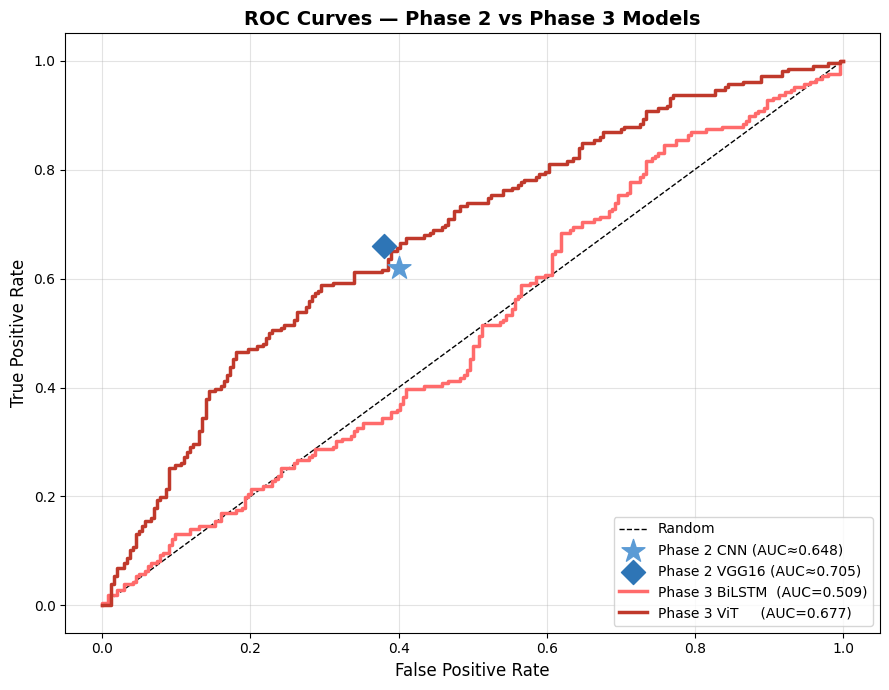

Saved → phase3_roc_comparison.png


In [25]:
fig, ax = plt.subplots(figsize=(9, 7))

# Phase 2 baseline
ax.plot([0, 1], [0, 1], 'k--', lw=1, label='Random')

# Phase 2 CNN (approximate from saved metrics)
# We show a reference marker since we don't have the raw probabilities here
ax.scatter([1 - 0.60], [0.62], marker='*', s=300, color='#5B9BD5',
           label=f'Phase 2 CNN (AUC≈{PHASE2_CNN_AUC:.3f})', zorder=5)
ax.scatter([1 - 0.62], [0.66], marker='D', s=150, color='#2E75B6',
           label=f'Phase 2 VGG16 (AUC≈{PHASE2_VGG_AUC:.3f})', zorder=5)

# Phase 3 LSTM
ax.plot(fpr_lstm, tpr_lstm, color='#FF6B6B', lw=2.5,
        label=f'Phase 3 BiLSTM  (AUC={auc_lstm:.3f})')

# Phase 3 ViT
ax.plot(fpr_vit, tpr_vit, color='#C0392B', lw=2.5,
        label=f'Phase 3 ViT     (AUC={auc_vit:.3f})')

ax.set_xlabel('False Positive Rate', fontsize=12)
ax.set_ylabel('True Positive Rate', fontsize=12)
ax.set_title('ROC Curves — Phase 2 vs Phase 3 Models', fontsize=14, fontweight='bold')
ax.legend(fontsize=10, loc='lower right')
ax.grid(alpha=0.35)

plt.tight_layout()
plt.savefig('phase3_roc_comparison.png', dpi=180, bbox_inches='tight')
plt.show()
print('Saved → phase3_roc_comparison.png')

## 📝 Cell 23: Phase 3 Summary & Analysis

In [26]:
lstm_vs_cnn_acc = acc_lstm - PHASE2_CNN_ACC
lstm_vs_cnn_auc = auc_lstm - PHASE2_CNN_AUC
vit_vs_cnn_acc  = acc_vit  - PHASE2_CNN_ACC
vit_vs_cnn_auc  = auc_vit  - PHASE2_CNN_AUC

def delta(v):
    return f'+{v:.4f}' if v >= 0 else f'{v:.4f}'

print('='*70)
print('PHASE 3 — FINAL SUMMARY')
print('='*70)
print()
print('📌 Dataset: NIH Chest X-Ray — Binary (Normal vs Diseased)')
print(f'   Train: {len(train_df):,} | Val: {len(val_df):,} | Test: {len(test_df):,}')
print()
print('─'*70)
print(f'BiLSTM Model:')
print(f'  Architecture : Bidirectional LSTM (128→64) + LSTM(32) + FC')
print(f'  Input        : 128 rows × 128 pixels (rows as time steps)')
print(f'  Test Acc  = {acc_lstm:.4f}  vs CNN {PHASE2_CNN_ACC} ({delta(lstm_vs_cnn_acc)})')
print(f'  Test F1   = {f1_lstm:.4f}  vs CNN {PHASE2_CNN_F1}')
print(f'  Test AUC  = {auc_lstm:.4f}  vs CNN {PHASE2_CNN_AUC} ({delta(lstm_vs_cnn_auc)})')
print()
print('─'*70)
print(f'Vision Transformer (ViT-Base/16) — Fine-tuned:')
print(f'  Architecture : ViT-B/16 (last 4 blocks unfrozen) + custom head')
print(f'  Input        : 224×224 RGB, patch_size=16 (196 patches)')
print(f'  Pretrained   : ImageNet (timm library)')
print(f'  Test Acc  = {acc_vit:.4f}  vs CNN {PHASE2_CNN_ACC} ({delta(vit_vs_cnn_acc)})')
print(f'  Test F1   = {f1_vit:.4f}  vs CNN {PHASE2_CNN_F1}')
print(f'  Test AUC  = {auc_vit:.4f}  vs CNN {PHASE2_CNN_AUC} ({delta(vit_vs_cnn_auc)})')
print()
print('─'*70)
print('Attention Visualization:')
print('  ✅ CLS-token attention maps extracted from last transformer block')
print('  ✅ 12-head per-head visualization generated')
print('  ✅ Heatmaps overlaid on original chest X-rays')
print('  ✅ Normal vs Diseased attention patterns compared')
print()
print('─'*70)
best_phase3 = 'ViT' if auc_vit >= auc_lstm else 'BiLSTM'
best_auc    = max(auc_vit, auc_lstm)
print(f'🏆 Best Phase 3 Model: {best_phase3} (AUC={best_auc:.4f})')
print('='*70)

PHASE 3 — FINAL SUMMARY

📌 Dataset: NIH Chest X-Ray — Binary (Normal vs Diseased)
   Train: 2,099 | Val: 451 | Test: 450

──────────────────────────────────────────────────────────────────────
BiLSTM Model:
  Architecture : Bidirectional LSTM (128→64) + LSTM(32) + FC
  Input        : 128 rows × 128 pixels (rows as time steps)
  Test Acc  = 0.4933  vs CNN 0.614 (-0.1207)
  Test F1   = 0.5230  vs CNN 0.621
  Test AUC  = 0.5086  vs CNN 0.648 (-0.1394)

──────────────────────────────────────────────────────────────────────
Vision Transformer (ViT-Base/16) — Fine-tuned:
  Architecture : ViT-B/16 (last 4 blocks unfrozen) + custom head
  Input        : 224×224 RGB, patch_size=16 (196 patches)
  Pretrained   : ImageNet (timm library)
  Test Acc  = 0.5467  vs CNN 0.614 (-0.0673)
  Test F1   = 0.6542  vs CNN 0.621
  Test AUC  = 0.6772  vs CNN 0.648 (+0.0292)

──────────────────────────────────────────────────────────────────────
Attention Visualization:
  ✅ CLS-token attention maps extracted fro

## 💾 Cell 24: Save All Results

In [27]:
# Save comparison table to CSV
comparison_df.to_csv('phase3_results.csv', index=False)
print('Saved → phase3_results.csv')

# Save LSTM model
lstm_model.save('phase3_lstm_model.keras')
print('Saved → phase3_lstm_model.keras')

# ViT already saved as best_vit.pth
print('Saved → best_vit.pth')

print()
print('📁 Output files:')
files = [
    'lstm_training_curves.png',
    'lstm_evaluation.png',
    'vit_training_curves.png',
    'vit_evaluation.png',
    'vit_attention_heatmaps.png',
    'vit_attention_heads.png',
    'phase3_final_comparison.png',
    'phase3_roc_comparison.png',
    'phase3_results.csv',
    'phase3_lstm_model.keras',
    'best_vit.pth',
    'best_lstm.keras',
]
for f in files:
    exists = '✅' if os.path.exists(f) else '❌ (will be created on run)'
    print(f'  {exists} {f}')

Saved → phase3_results.csv
Saved → phase3_lstm_model.keras
Saved → best_vit.pth

📁 Output files:
  ✅ lstm_training_curves.png
  ✅ lstm_evaluation.png
  ✅ vit_training_curves.png
  ✅ vit_evaluation.png
  ✅ vit_attention_heatmaps.png
  ✅ vit_attention_heads.png
  ✅ phase3_final_comparison.png
  ✅ phase3_roc_comparison.png
  ✅ phase3_results.csv
  ✅ phase3_lstm_model.keras
  ✅ best_vit.pth
  ✅ best_lstm.keras
